# S08 — Sensitivity analyses

This notebook performs pre-specified sensitivity analyses for the association between thyroid autoimmunity (TAI) and cardiometabolic endpoints in PCOS.

Sensitivity set:
1) Base model (full eligible cohort): TAI_A
2) Euthyroid-only restriction (TSH reference range): TAI_A
3) Alternative TAI definitions: TAI_B, TAI_C
4) Outlier robustness: 1%/99% trimming on endpoint-driving continuous variables

#Endpoints:
- ep_primary
- ep_non_hdl
- ep_ogtt120

Outputs:
- TableS1_sensitivity.csv
- F10_robustness_forest.png
- s8_sensitivity_summary.json

## Import

In [ ]:
import json
import logging
from pathlib import Path
from typing import List, Tuple, Dict, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit

## Config

In [ ]:
def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def resolve_config_path() -> Path:
    candidates = [
        Path("/content/reports/config_snapshot.json"),
        Path("/mnt/data/config_snapshot.json"),
        Path("/content/config.json"),
        Path("/mnt/data/config.json"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("No config found.")

CONFIG_PATH = resolve_config_path()
CFG = load_json(CONFIG_PATH)

print("Loaded config:", CONFIG_PATH)

Loaded config: /content/config.json


## Directories and logging

In [ ]:
def ensure_dirs(cfg: dict) -> None:
    path_keys = [
        "output_dir",
        "intermediate_dir",
        "figures_dir",
        "tables_dir",
        "models_dir",
        "reports_dir",
        "qc_dir",
        "supplementary_dir",
    ]
    for key in path_keys:
        if key in cfg.get("paths", {}):
            Path(cfg["paths"][key]).mkdir(parents=True, exist_ok=True)

def setup_logging(cfg: dict) -> None:
    if not cfg.get("logging", {}).get("enabled", False):
        return

    root_logger = logging.getLogger()
    if root_logger.handlers:
        root_logger.setLevel(logging.INFO)
        return

    log_file = Path(cfg["logging"]["log_file"])
    log_file.parent.mkdir(parents=True, exist_ok=True)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file, encoding="utf-8"),
            logging.StreamHandler(),
        ],
    )
    logging.info("Logging initialized in S8.")
    logging.info("Config loaded from: %s", str(CONFIG_PATH))

ensure_dirs(CFG)
setup_logging(CFG)

tables_dir = Path(CFG["paths"]["tables_dir"])
figures_dir = Path(CFG["paths"]["figures_dir"])
reports_dir = Path(CFG["paths"]["reports_dir"])
intermediate_dir = Path(CFG["paths"]["intermediate_dir"])

RANDOM_SEED = int(CFG["project"]["random_seed"])
rng = np.random.default_rng(RANDOM_SEED)

## Data loading

In [ ]:
def resolve_analysis_data_paths(cfg: dict):
    return [
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.parquet",
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.csv",
        Path("/content/pcos_analysis.parquet"),
        Path("/content/pcos_analysis.csv"),
        Path("/mnt/data/pcos_analysis.parquet"),
        Path("/mnt/data/pcos_analysis.csv"),
    ]

def load_analysis_dataset(cfg: dict):
    candidates = resolve_analysis_data_paths(cfg)

    for p in candidates:
        if p.exists():
            if p.suffix == ".parquet":
                try:
                    return pd.read_parquet(p), str(p)
                except Exception:
                    continue
            if p.suffix == ".csv":
                try:
                    return pd.read_csv(p), str(p)
                except Exception:
                    continue

    raise FileNotFoundError("No analysis dataset found.")

df, source_used = load_analysis_dataset(CFG)

print("Loaded:", source_used)
print("Shape:", df.shape)
df.head(3)

Loaded: /content/pcos_analysis.parquet
Shape: (1300, 77)


,id,age,anti_tpo,anti_tg,tsh,ft4,ft3,tg,hdl,tc,...,analysis_primary_minimal,analysis_non_hdl_minimal,analysis_ogtt120_minimal,exposure_tai_A_defined,endpoint_primary_defined,endpoint_non_hdl_defined,endpoint_ogtt120_defined,analysis_primary_eligible,analysis_non_hdl_eligible,analysis_ogtt120_eligible
0,7611,25.0,13.8,NaN,0.969,1.20,NaN,116.0,56.6,188.0,...,True,True,True,True,True,True,True,True,True,True
1,8133,25.0,12.6,NaN,2.050,1.18,NaN,144.0,41.9,196.0,...,True,True,True,True,True,True,True,True,True,True
2,11028,25.0,150.0,NaN,2.500,1.29,NaN,35.8,62.7,133.0,...,True,True,True,True,True,True,True,True,True,True


## Analysis settings

In [ ]:
ENDPOINTS = ["ep_primary", "ep_non_hdl", "ep_ogtt120"]
ENDPOINTS = [e for e in ENDPOINTS if e in df.columns]

EXPOSURES = ["tai_A", "tai_B", "tai_C"]
EXPOSURES = [x for x in EXPOSURES if x in df.columns]

if "ep_primary" not in ENDPOINTS:
    raise KeyError("ep_primary not found. Run S03 first.")
if "tai_A" not in EXPOSURES:
    raise KeyError("tai_A not found. Run S03 first.")

EUTH_FLAG = "euthyroid_tsh_only"
HAS_EUTH = EUTH_FLAG in df.columns

ENDPOINT_SPECS = {
    "ep_primary": {
        "eligibility_flag": "analysis_primary_eligible",   # <- sprawdź nazwę w S03
        "trim_var": "tg_hdl_ratio",
        "label": "Primary endpoint",
    },
    "ep_non_hdl": {
        "eligibility_flag": "analysis_non_hdl_eligible",
        "trim_var": "non_hdl",
        "label": "non-HDL ≥ 130 mg/dL",
    },
    "ep_ogtt120": {
        "eligibility_flag": "analysis_ogtt120_eligible",
        "trim_var": "glu120",
        "label": "OGTT 120' glucose ≥ 140 mg/dL",
    },
}

print("Endpoints:", ENDPOINTS)
print("Exposures:", EXPOSURES)
print("Has euthyroid flag:", HAS_EUTH)

Endpoints: ['ep_primary', 'ep_non_hdl', 'ep_ogtt120']
Exposures: ['tai_A', 'tai_B', 'tai_C']
Has euthyroid flag: True


## Trimming helpers

In [ ]:
TRIM_Q_LOW = 0.01
TRIM_Q_HIGH = 0.99

def trim_variable(df_in: pd.DataFrame, var: str, q_low: float = 0.01, q_high: float = 0.99):
    df2 = df_in.copy()

    if var not in df2.columns:
        return df2, 0, np.nan, np.nan

    s = pd.to_numeric(df2[var], errors="coerce")
    n_measured = int(s.notna().sum())

    if n_measured < 10:
        return df2, 0, np.nan, np.nan

    lo = float(s.quantile(q_low))
    hi = float(s.quantile(q_high))

    keep = s.isna() | ((s >= lo) & (s <= hi))
    n_dropped = int((~keep & s.notna()).sum())

    return df2.loc[keep].copy(), n_dropped, lo, hi

def apply_endpoint_trim(df_in: pd.DataFrame, endpoint: str):
    spec = ENDPOINT_SPECS.get(endpoint, {})
    trim_var = spec.get("trim_var", "")
    if not trim_var:
        return df_in.copy(), "", 0, np.nan, np.nan

    df2, n_dropped, lo, hi = trim_variable(
        df_in,
        trim_var,
        q_low=TRIM_Q_LOW,
        q_high=TRIM_Q_HIGH
    )
    return df2, trim_var, n_dropped, lo, hi

## Firth logistic helpers

In [ ]:
def add_intercept(X: np.ndarray) -> np.ndarray:
    return np.column_stack([np.ones(X.shape[0]), X])

def _safe_expit(z: np.ndarray) -> np.ndarray:
    return np.clip(expit(z), 1e-10, 1 - 1e-10)

def _firth_step_components(X: np.ndarray, y: np.ndarray, beta: np.ndarray):
    eta = X @ beta
    p = _safe_expit(eta)
    W = np.clip(p * (1 - p), 1e-10, None)

    XtWX = X.T @ (W[:, None] * X)
    XtWX_inv = np.linalg.pinv(XtWX)

    quad = np.einsum("ij,jk,ik->i", X, XtWX_inv, X)
    h = np.clip(W * quad, 0.0, 1.0)

    a = h * (0.5 - p)
    U_star = X.T @ (y - p + a)

    return p, W, XtWX, XtWX_inv, h, a, U_star

def fit_firth_logistic(
    X: np.ndarray,
    y: np.ndarray,
    maxiter: int = 200,
    tol: float = 1e-8,
    max_halving: int = 25
) -> Dict[str, Any]:

    beta = np.zeros(X.shape[1], dtype=float)

    def penalized_objective(b: np.ndarray) -> float:
        eta = X @ b
        p = _safe_expit(eta)
        W = np.clip(p * (1 - p), 1e-10, None)
        XtWX = X.T @ (W[:, None] * X)
        sign, logdet = np.linalg.slogdet(XtWX)
        if sign <= 0:
            return np.inf
        loglik = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
        return -(loglik + 0.5 * logdet)

    obj = penalized_objective(beta)
    converged = False
    message = "Maximum iterations reached"

    for it in range(1, maxiter + 1):
        p, W, XtWX, XtWX_inv, h, a, U_star = _firth_step_components(X, y, beta)
        step = XtWX_inv @ U_star

        if np.max(np.abs(U_star)) < tol and np.max(np.abs(step)) < tol:
            converged = True
            message = "Converged"
            break

        beta_candidate = beta + step
        obj_candidate = penalized_objective(beta_candidate)

        halving = 0
        while (not np.isfinite(obj_candidate) or obj_candidate > obj) and halving < max_halving:
            step = step / 2.0
            beta_candidate = beta + step
            obj_candidate = penalized_objective(beta_candidate)
            halving += 1

        if np.isfinite(obj_candidate) and obj_candidate <= obj:
            beta = beta_candidate
            obj = obj_candidate
        else:
            message = "Step-halving failed to improve objective"
            break

        if np.max(np.abs(step)) < tol:
            converged = True
            message = "Converged"
            break

    eta = X @ beta
    p = _safe_expit(eta)
    W = np.clip(p * (1 - p), 1e-10, None)
    XtWX = X.T @ (W[:, None] * X)

    return {
        "beta": beta,
        "p": p,
        "cov": np.linalg.pinv(XtWX),
        "converged": bool(converged),
        "message": str(message),
        "n_iter": int(it),
        "objective": float(obj),
        "optimizer": "firth_adjusted_score",
    }

def bootstrap_firth_or_ci(
    X: np.ndarray,
    y: np.ndarray,
    term_names: List[str],
    n_boot: int,
    seed: int
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(y)
    boot_betas = []
    n_nonconverged = 0
    n_failed = 0

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Xb = X[idx]
        yb = y[idx]

        if len(np.unique(yb)) < 2:
            n_failed += 1
            continue

        try:
            fit_b = fit_firth_logistic(Xb, yb)
            if not fit_b["converged"]:
                n_nonconverged += 1
            boot_betas.append(fit_b["beta"])
        except Exception:
            n_failed += 1
            continue

    if len(boot_betas) == 0:
        raise RuntimeError("No successful bootstrap fits for Firth model.")

    boot_betas = np.asarray(boot_betas)

    rows = []
    for j, term in enumerate(term_names):
        vals = boot_betas[:, j]
        rows.append({
            "term": term,
            "CI_low": float(np.exp(np.quantile(vals, 0.025))),
            "CI_high": float(np.exp(np.quantile(vals, 0.975))),
            "n_boot_success": int(len(boot_betas)),
            "n_boot_nonconverged": int(n_nonconverged),
            "n_boot_failed_or_skipped": int(n_failed),
        })
    return pd.DataFrame(rows)

## Cohort builder for binary sensitivity models

In [ ]:
def to_bool01(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

def build_binary_cohort(
    df_in: pd.DataFrame,
    endpoint: str,
    eligibility_flag: str,
    exposure: str,
    age_col: str = "age",
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, float]:
    required = [eligibility_flag, exposure, endpoint, age_col]
    missing_required = [c for c in required if c not in df_in.columns]
    if missing_required:
        raise KeyError(f"Missing required columns: {missing_required}")

    dfm = df_in.loc[df_in[eligibility_flag] == True].copy()
    dfm = dfm[dfm[exposure].notna() & dfm[endpoint].notna() & dfm[age_col].notna()].copy()
    dfm = dfm.reset_index(drop=True)

    X = pd.DataFrame({
        "TAI": to_bool01(dfm[exposure]).astype(float),
        "age_num": to_num(dfm[age_col]),
    })

    age_mean = float(X["age_num"].mean())
    X["age_c"] = X["age_num"] - age_mean
    X = X[["TAI", "age_c"]]

    y = to_bool01(dfm[endpoint]).astype(int)

    mask = X.notna().all(axis=1) & y.notna()
    X = X.loc[mask].reset_index(drop=True)
    y = y.loc[mask].reset_index(drop=True)
    dfm = dfm.loc[mask.to_numpy()].reset_index(drop=True)

    return dfm, X, y, age_mean

def summarize_events(dfm: pd.DataFrame, exposure: str, endpoint: str) -> Dict[str, int]:
    y = to_bool01(dfm[endpoint]).astype(int)
    x = to_bool01(dfm[exposure]).astype(int)
    return {
        "n": int(len(dfm)),
        "events": int(y.sum()),
        "n_tai_pos": int((x == 1).sum()),
        "n_tai_neg": int((x == 0).sum()),
        "events_tai_pos": int(((x == 1) & (y == 1)).sum()),
        "events_tai_neg": int(((x == 0) & (y == 1)).sum()),
    }

## Sensitivity variants

In [ ]:
variants = [
    {
        "variant": "base_TAI_A",
        "exposure": "tai_A",
        "filter": None,
        "trim": False,
        "description": "Base analysis with TAI definition A",
    }
]

if HAS_EUTH:
    variants.append({
        "variant": "euthyroid_TAI_A",
        "exposure": "tai_A",
        "filter": (pd.to_numeric(df[EUTH_FLAG], errors="coerce") == 1),
        "trim": False,
        "description": "Restriction to euthyroid participants",
    })

if "tai_B" in df.columns:
    variants.append({
        "variant": "base_TAI_B",
        "exposure": "tai_B",
        "filter": None,
        "trim": False,
        "description": "Alternative TAI definition B",
    })

if "tai_C" in df.columns:
    variants.append({
        "variant": "base_TAI_C",
        "exposure": "tai_C",
        "filter": None,
        "trim": False,
        "description": "Alternative TAI definition C",
    })

variants.append({
    "variant": "trim01_99_TAI_A",
    "exposure": "tai_A",
    "filter": None,
    "trim": True,
    "description": "Outlier robustness using 1%/99% trimming",
})

print("Sensitivity variants:")
for v in variants:
    print("-", v["variant"])

Sensitivity variants:
- base_TAI_A
- euthyroid_TAI_A
- base_TAI_B
- base_TAI_C
- trim01_99_TAI_A


## Run sensitivity models

In [ ]:
N_BOOT = 2000
rows = []

for v in variants:
    for ep in ENDPOINTS:
        df_model = df.copy()

        if v["filter"] is not None:
            df_model = df_model.loc[v["filter"]].copy()

        n_before_trim = int(len(df_model))
        n_after_trim = int(len(df_model))
        n_trimmed = 0
        trim_var = ""
        trim_low = np.nan
        trim_high = np.nan

        if v["trim"]:
            df_model, trim_var, n_trimmed, trim_low, trim_high = apply_endpoint_trim(df_model, ep)
            n_after_trim = int(len(df_model))

        try:
            eligibility_flag = ENDPOINT_SPECS[ep]["eligibility_flag"]

            dfm, X, y, age_mean = build_binary_cohort(
                df_in=df_model,
                endpoint=ep,
                eligibility_flag=eligibility_flag,
                exposure=v["exposure"],
                age_col="age",
            )

            X_np = X.to_numpy(dtype=float)
            y_np = y.to_numpy(dtype=int)
            X_design = add_intercept(X_np)
            term_names = ["Intercept"] + list(X.columns)

            if len(np.unique(y_np)) < 2:
                raise RuntimeError("No outcome variation in this cohort.")

            fit = fit_firth_logistic(X_design, y_np)
            boot = bootstrap_firth_or_ci(
                X=X_design,
                y=y_np,
                term_names=term_names,
                n_boot=N_BOOT,
                seed=RANDOM_SEED,
            )

            tai_row = boot.loc[boot["term"] == "TAI"]
            if tai_row.empty:
                raise RuntimeError("TAI term not found in bootstrap output.")
            tai_row = tai_row.iloc[0]

            evt = summarize_events(dfm, v["exposure"], ep)

            rows.append({
                "variant": v["variant"],
                "variant_description": v["description"],
                "endpoint": ep,
                "endpoint_label": ENDPOINT_SPECS[ep]["label"],
                "exposure": v["exposure"],
                "eligibility_flag": eligibility_flag,
                "status": "ok",

                "n": evt["n"],
                "events": evt["events"],
                "n_tai_pos": evt["n_tai_pos"],
                "n_tai_neg": evt["n_tai_neg"],
                "events_tai_pos": evt["events_tai_pos"],
                "events_tai_neg": evt["events_tai_neg"],

                "OR": float(np.exp(fit["beta"][1])),
                "CI_low": float(tai_row["CI_low"]),
                "CI_high": float(tai_row["CI_high"]),

                "n_boot_success": int(tai_row["n_boot_success"]),
                "n_boot_nonconverged": int(tai_row["n_boot_nonconverged"]),
                "n_boot_failed_or_skipped": int(tai_row["n_boot_failed_or_skipped"]),

                "converged": bool(fit["converged"]),
                "optimizer_message": fit["message"],
                "n_iter": int(fit["n_iter"]),
                "age_centering_mean": float(age_mean),

                "trim_applied": bool(v["trim"]),
                "trim_var": trim_var,
                "trim_q_low": float(TRIM_Q_LOW) if v["trim"] else np.nan,
                "trim_q_high": float(TRIM_Q_HIGH) if v["trim"] else np.nan,
                "trim_low_value": trim_low,
                "trim_high_value": trim_high,
                "n_before_trim": n_before_trim,
                "n_after_trim": n_after_trim,
                "n_trimmed": int(n_trimmed),
            })

        except Exception as e:
            rows.append({
                "variant": v["variant"],
                "variant_description": v["description"],
                "endpoint": ep,
                "endpoint_label": ENDPOINT_SPECS.get(ep, {}).get("label", ep),
                "exposure": v["exposure"],
                "status": f"failed: {repr(e)}",
                "trim_applied": bool(v["trim"]),
                "trim_var": trim_var,
                "trim_q_low": float(TRIM_Q_LOW) if v["trim"] else np.nan,
                "trim_q_high": float(TRIM_Q_HIGH) if v["trim"] else np.nan,
                "trim_low_value": trim_low,
                "trim_high_value": trim_high,
                "n_before_trim": n_before_trim,
                "n_after_trim": n_after_trim,
                "n_trimmed": int(n_trimmed),
            })

sens = pd.DataFrame(rows)

out = tables_dir / "TableS1_sensitivity.csv"
sens.to_csv(out, index=False)

print("Saved:", out)
print(sens[["variant", "endpoint", "status"]])
sens.head(20)

Saved: /content/outputs/tables/TableS1_sensitivity.csv
            variant    endpoint status
0        base_TAI_A  ep_primary     ok
1        base_TAI_A  ep_non_hdl     ok
2        base_TAI_A  ep_ogtt120     ok
3   euthyroid_TAI_A  ep_primary     ok
4   euthyroid_TAI_A  ep_non_hdl     ok
5   euthyroid_TAI_A  ep_ogtt120     ok
6        base_TAI_B  ep_primary     ok
7        base_TAI_B  ep_non_hdl     ok
8        base_TAI_B  ep_ogtt120     ok
9        base_TAI_C  ep_primary     ok
10       base_TAI_C  ep_non_hdl     ok
11       base_TAI_C  ep_ogtt120     ok
12  trim01_99_TAI_A  ep_primary     ok
13  trim01_99_TAI_A  ep_non_hdl     ok
14  trim01_99_TAI_A  ep_ogtt120     ok


,variant,variant_description,endpoint,endpoint_label,exposure,eligibility_flag,status,n,events,n_tai_pos,...,age_centering_mean,trim_applied,trim_var,trim_q_low,trim_q_high,trim_low_value,trim_high_value,n_before_trim,n_after_trim,n_trimmed
0,base_TAI_A,Base analysis with TAI definition A,ep_primary,Primary endpoint,tai_A,analysis_primary_eligible,ok,1053,70,84,...,21.441595,False,,NaN,NaN,NaN,NaN,1300,1300,0
1,base_TAI_A,Base analysis with TAI definition A,ep_non_hdl,non-HDL ≥ 130 mg/dL,tai_A,analysis_non_hdl_eligible,ok,1053,224,84,...,21.441595,False,,NaN,NaN,NaN,NaN,1300,1300,0
2,base_TAI_A,Base analysis with TAI definition A,ep_ogtt120,OGTT 120' glucose ≥ 140 mg/dL,tai_A,analysis_ogtt120_eligible,ok,1035,156,79,...,21.442512,False,,NaN,NaN,NaN,NaN,1300,1300,0
3,euthyroid_TAI_A,Restriction to euthyroid participants,ep_primary,Primary endpoint,tai_A,analysis_primary_eligible,ok,1005,66,69,...,21.452736,False,,NaN,NaN,NaN,NaN,1122,1122,0
4,euthyroid_TAI_A,Restriction to euthyroid participants,ep_non_hdl,non-HDL ≥ 130 mg/dL,tai_A,analysis_non_hdl_eligible,ok,1005,215,69,...,21.452736,False,,NaN,NaN,NaN,NaN,1122,1122,0
5,euthyroid_TAI_A,Restriction to euthyroid participants,ep_ogtt120,OGTT 120' glucose ≥ 140 mg/dL,tai_A,analysis_ogtt120_eligible,ok,987,151,64,...,21.453901,False,,NaN,NaN,NaN,NaN,1122,1122,0
6,base_TAI_B,Alternative TAI definition B,ep_primary,Primary endpoint,tai_B,analysis_primary_eligible,ok,1053,70,14,...,21.441595,False,,NaN,NaN,NaN,NaN,1300,1300,0
7,base_TAI_B,Alternative TAI definition B,ep_non_hdl,non-HDL ≥ 130 mg/dL,tai_B,analysis_non_hdl_eligible,ok,1053,224,14,...,21.441595,False,,NaN,NaN,NaN,NaN,1300,1300,0
8,base_TAI_B,Alternative TAI definition B,ep_ogtt120,OGTT 120' glucose ≥ 140 mg/dL,tai_B,analysis_ogtt120_eligible,ok,1035,156,14,...,21.442512,False,,NaN,NaN,NaN,NaN,1300,1300,0
9,base_TAI_C,Alternative TAI definition C,ep_primary,Primary endpoint,tai_C,analysis_primary_eligible,ok,1053,70,53,...,21.441595,False,,NaN,NaN,NaN,NaN,1300,1300,0


## Forest plot

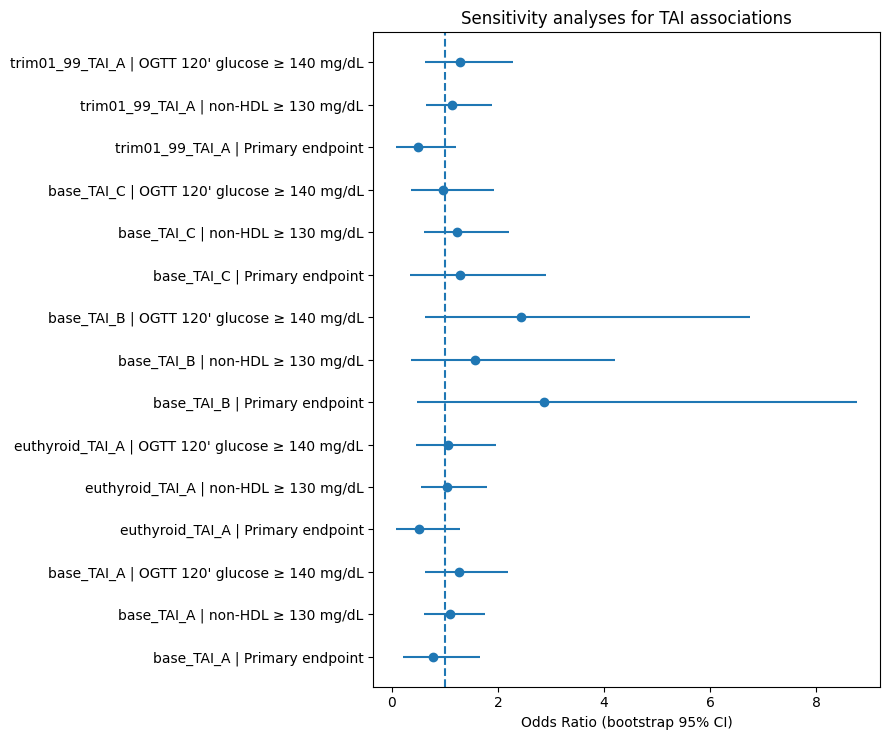

Saved: /content/outputs/figures/F10_robustness_forest.png


In [ ]:
plot_df = sens[sens["status"] == "ok"].copy().reset_index(drop=True)

if plot_df.empty:
    raise RuntimeError(
        "No successful sensitivity models to plot. Check sens[['variant','endpoint','status']]."
    )

plot_df["plot_label"] = plot_df["variant"] + " | " + plot_df["endpoint_label"]

plt.figure(figsize=(9, max(4.5, 0.5 * len(plot_df))))

y = np.arange(len(plot_df))
or_vals = plot_df["OR"].to_numpy(dtype=float)
lo_vals = plot_df["CI_low"].to_numpy(dtype=float)
hi_vals = plot_df["CI_high"].to_numpy(dtype=float)

plt.hlines(y, lo_vals, hi_vals)
plt.plot(or_vals, y, "o")
plt.axvline(1.0, linestyle="--")

plt.yticks(y, plot_df["plot_label"])
plt.xlabel("Odds Ratio (bootstrap 95% CI)")
plt.title("Sensitivity analyses for TAI associations")
plt.tight_layout()

out_fig = figures_dir / "F10_robustness_forest.png"
plt.savefig(out_fig, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_fig)

## Summary JSON

In [ ]:
summary = {
    "analysis": "sensitivity_analyses",
    "source_data": source_used,
    "endpoints": ENDPOINTS,
    "variants": [v["variant"] for v in variants],
    "n_results_total": int(len(sens)),
    "n_results_ok": int((sens["status"] == "ok").sum()),
    "n_results_failed": int((sens["status"] != "ok").sum()),
    "ok_results": sens.loc[sens["status"] == "ok", [
        "variant", "endpoint", "endpoint_label", "exposure",
        "n", "events", "OR", "CI_low", "CI_high", "n_trimmed"
    ]].to_dict(orient="records"),
}

out_json = reports_dir / "s8_sensitivity_summary.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:", out_json)
summary

Saved: /content/reports/s8_sensitivity_summary.json


{'analysis': 'sensitivity_analyses',
 'source_data': '/content/pcos_analysis.parquet',
 'endpoints': ['ep_primary', 'ep_non_hdl', 'ep_ogtt120'],
 'variants': ['base_TAI_A',
  'euthyroid_TAI_A',
  'base_TAI_B',
  'base_TAI_C',
  'trim01_99_TAI_A'],
 'n_results_total': 15,
 'n_results_ok': 15,
 'n_results_failed': 0,
 'ok_results': [{'variant': 'base_TAI_A',
   'endpoint': 'ep_primary',
   'endpoint_label': 'Primary endpoint',
   'exposure': 'tai_A',
   'n': 1053,
   'events': 70,
   'OR': 0.7658349805993099,
   'CI_low': 0.2108528694966625,
   'CI_high': 1.66581638021192,
   'n_trimmed': 0},
  {'variant': 'base_TAI_A',
   'endpoint': 'ep_non_hdl',
   'endpoint_label': 'non-HDL ≥ 130 mg/dL',
   'exposure': 'tai_A',
   'n': 1053,
   'events': 224,
   'OR': 1.0912202311240955,
   'CI_low': 0.6116881886188331,
   'CI_high': 1.7630873053904657,
   'n_trimmed': 0},
  {'variant': 'base_TAI_A',
   'endpoint': 'ep_ogtt120',
   'endpoint_label': "OGTT 120' glucose ≥ 140 mg/dL",
   'exposure': 'ta

## Note

# Interpretation notes for manuscript

These sensitivity analyses were performed to evaluate the robustness of the association between thyroid autoimmunity and cardiometabolic outcomes.

All binary models were estimated using the same Firth logistic regression framework as in the primary and secondary analyses to ensure methodological consistency across the pipeline.

The sensitivity framework examined:
- restriction to euthyroid participants,
- alternative TAI definitions,
- robustness to extreme values via 1%/99% trimming of endpoint-driving variables.

These analyses are supportive and should be interpreted as robustness checks relative to the main prespecified models from S05 and S06.

This notebook evaluates the robustness of the association between thyroid autoimmunity (TAI) and cardiometabolic endpoints in women with PCOS using several pre-specified sensitivity analyses.

All models were estimated using the same Firth logistic regression framework as in the primary (S05) and secondary (S06) analyses, ensuring methodological consistency across the analytical pipeline.

The sensitivity framework examined three main aspects:

Restriction to euthyroid participants, testing whether associations persist when individuals with overt thyroid dysfunction are excluded.

Alternative definitions of thyroid autoimmunity (TAI_B and TAI_C), assessing whether results depend on the operational definition of exposure.

Robustness to extreme observations, using 1%/99% trimming of endpoint-driving continuous variables (TG/HDL ratio, non-HDL cholesterol, and OGTT 120-minute glucose).

Across these analyses, the estimated odds ratios for TAI_A remained broadly consistent with the main models. Restricting the analysis to euthyroid individuals and applying trimming of extreme values did not materially change the magnitude or direction of the associations. Confidence intervals generally overlapped those from the primary analyses.

Alternative TAI definitions (TAI_B and TAI_C) yielded more variable and less precise estimates, reflected in substantially wider confidence intervals. This pattern likely reflects smaller effective sample sizes or rarer exposure definitions rather than strong evidence of differential effects.

Overall, the sensitivity analyses did not reveal substantial instability of the main results, supporting the robustness of the findings reported in the primary and secondary regression models.

Importantly, these analyses should be interpreted as robustness checks rather than independent confirmatory tests, and the main inference of the study remains based on the prespecified regression models presented in S05 and S06.